# BlochLaplacian3D — Shifted Laplacian on an orthorhombic periodic cell

> **Artifact boundary.** This is notebook-local exploratory teaching material.
> It is not a canonical artifact, supported PhysKit API, real-material model,
> or claim of pedagogical validation. Deterministic plots and numerical outputs
> are embedded so students can inspect the lesson before rerunning it.
>
> Accepted local contract: `docs/harness/physkit.harness.09-dimensional-periodic-solids-notebook-series-contract.md`  
> Accepted contract SHA-256: `97736dc9bb9a5fcd3561b51fea8b2869ecbe1bbb4d1a8b7b2df9d0b4313b9ce9`

## Question

How is the Bloch kinetic operator assembled and checked in three dimensions without dense matrices?

## Learning objectives

- Assemble the 3D shifted Laplacian as a sparse Kronecker sum.
- Verify Hermiticity and matrix dimensions.
- Compare low eigenvalues with summed one-dimensional Fourier references.
- Recover the constant periodic mode at $\mathbf k=0$.

## Shared conventions

Primary calculations use reduced units with $\\hbar^2/(2m)=1$. The first twelve
notebooks use unit baseline box or orthogonal-cell lengths; the final metric
notebooks explicitly define their non-orthogonal lattice bases. PIAB plotting
grids include both hard-wall endpoints. Periodic finite-difference grids are
endpoint-exclusive. Multidimensional meshes use `indexing="ij"` and C-order
flattening, so the last coordinate varies fastest. Eigensolver vectors use
Euclidean normalization; any sampled wavefunction normalization is separately
labelled as uniform quadrature. All helper functions are transparent
notebook-local teaching code, not a public API.

## Connection to the sequence

This completes orthogonal Bloch-Laplacian construction before adding a periodic potential.


## Three-dimensional shifted operator

For an orthorhombic cell,

$$
\nabla_{\mathbf k}^2=\sum_{i=x,y,z}(\partial_i+ik_i)^2.
$$

The finite operator is a three-term Kronecker sum. Sparse storage preserves the
six-neighbor stencil and avoids an unnecessary dense $N^3\times N^3$ matrix.
The full state still obeys the unshifted differential expression; this shifted
link-phase representation acts on its periodic factor and is not identified
with a naive finite discretization of the expanded continuum derivative.


In [1]:
import numpy as np
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from io import BytesIO
from IPython.display import Image, display
from scipy import sparse
from scipy.sparse.linalg import eigsh


def bloch_laplacian_1d(n, length, k):
    """Gauge-consistent periodic finite-difference Bloch Laplacian."""
    h = length / n
    rows = np.repeat(np.arange(n), 3)
    columns = np.column_stack((
        (np.arange(n) - 1) % n,
        np.arange(n),
        (np.arange(n) + 1) % n,
    )).ravel()
    values = np.column_stack((
        np.full(n, np.exp(-1j * k * h) / h**2),
        np.full(n, -2.0 / h**2),
        np.full(n, np.exp(1j * k * h) / h**2),
    )).ravel()
    return sparse.coo_matrix((values, (rows, columns)), shape=(n, n)).tocsr()


def hermiticity_error(matrix):
    difference = matrix - matrix.getH()
    return 0.0 if difference.nnz == 0 else np.max(np.abs(difference.data))

np.set_printoptions(precision=6, suppress=True)


def show_figure(figure):
    """Render a deterministic PNG in notebook and saved-output frontends."""
    buffer = BytesIO()
    figure.savefig(buffer, format="png", dpi=120, bbox_inches="tight")
    display(Image(data=buffer.getvalue()))


In [2]:
shape = (9, 9, 9)
lengths = np.ones(3)
q = np.array([0.17, -0.11, 0.09])
k = 2 * np.pi * q / lengths
operators = [bloch_laplacian_1d(n, length, k_value)
             for n, length, k_value in zip(shape, lengths, k)]
identities = [sparse.identity(n, format="csr") for n in shape]
Lk = (sparse.kron(sparse.kron(operators[0], identities[1]), identities[2], format="csr")
      + sparse.kron(sparse.kron(identities[0], operators[1]), identities[2], format="csr")
      + sparse.kron(sparse.kron(identities[0], identities[1]), operators[2], format="csr"))
assert Lk.shape == (np.prod(shape), np.prod(shape))
assert np.issubdtype(Lk.dtype, np.complexfloating)
assert hermiticity_error(Lk) < 1e-12
print("matrix shape:", Lk.shape, "nnz:", Lk.nnz)
print("dense entries avoided:", Lk.shape[0] ** 2 - Lk.nnz)


matrix shape: (729, 729) nnz: 5103
dense entries avoided: 526338


In [3]:
spectra = []
for n, length, k_value in zip(shape, lengths, k):
    h = length / n
    G = 2 * np.pi * np.fft.fftfreq(n, d=h)
    spectra.append(4.0 / h**2 * np.sin(0.5 * (G + k_value) * h) ** 2)
reference = np.sort((spectra[0][:, None, None]
                     + spectra[1][None, :, None]
                     + spectra[2][None, None, :]).ravel())
eigenvalues, eigenvectors = eigsh(-Lk, k=6, which="SA", v0=np.ones(Lk.shape[0]))
order = np.argsort(eigenvalues)
numeric, eigenvectors = eigenvalues[order], eigenvectors[:, order]
residuals = np.array([
    np.linalg.norm((-Lk) @ eigenvectors[:, index] - value * eigenvectors[:, index])
    / max(1.0, abs(value))
    for index, value in enumerate(numeric)
])
assert np.allclose(numeric, reference[:6], rtol=1e-10, atol=1e-12)
assert np.max(residuals) < 1e-8
print("lowest kinetic eigenvalues:", numeric)
print("spectrum tolerance satisfied:", np.allclose(numeric, reference[:6], rtol=1e-10, atol=1e-12))
print("eigensolver residual bound satisfied:", np.max(residuals) < 1e-8)


lowest kinetic eigenvalues: [ 1.936712 27.241305 31.736934 33.224247 46.3012   47.714684]
spectrum tolerance satisfied: True
eigensolver residual bound satisfied: True


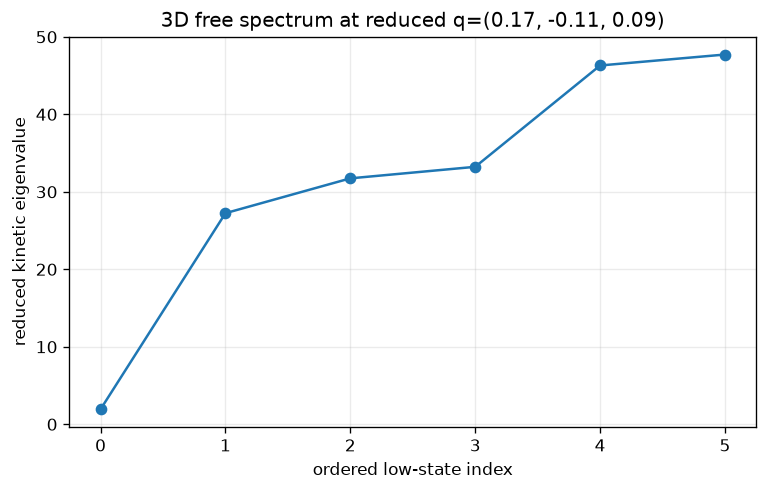

In [4]:
zero_ops = [bloch_laplacian_1d(n, length, 0.0) for n, length in zip(shape, lengths)]
L0 = (sparse.kron(sparse.kron(zero_ops[0], identities[1]), identities[2], format="csr")
      + sparse.kron(sparse.kron(identities[0], zero_ops[1]), identities[2], format="csr")
      + sparse.kron(sparse.kron(identities[0], identities[1]), zero_ops[2], format="csr"))
constant = np.ones(np.prod(shape), dtype=complex)
assert np.linalg.norm(L0 @ constant) < 1e-12

fig, ax = plt.subplots(figsize=(6.5, 4.2))
ax.plot(np.arange(len(numeric)), numeric, "o-")
ax.set(xlabel="ordered low-state index", ylabel="reduced kinetic eigenvalue",
       title=f"3D free spectrum at reduced q={tuple(float(value) for value in q)}")
ax.grid(alpha=0.25)
fig.tight_layout()
show_figure(fig)
plt.close(fig)


## Interpretation and limitations

Only low eigenvalues are computed, and the 9×9×9 grid is a bounded teaching baseline rather than a convergence study. The cell remains orthorhombic.

Successful execution checks only the stated formulas and finite calculations.
It is not, by itself, continuum convergence, physical validation, pedagogical
validation, uncertainty quantification, canonical status, or support.

## Connection forward

Bloch1D adds a synthetic periodic cosine potential to the shifted kinetic operator.
